### 1. Описание

**Задача**: Предсказание ухода клиента

**Метод**: Логистическая регрессия

**Источник данных**: [Telco Customer Churn Dataset](https://www.kaggle.com/datasets/mosapabdelghany/telcom-customer-churn-dataset)

### 2. Техническая настройка

**Импотрирем библиотеки**

In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

**Создаем DataFrame-источник**

In [2]:
source_df = pd.read_csv(r'C:\Users\kondrashovms\Downloads\Telco_Cusomer_Churn.csv')
source_df.drop(columns=['customerID'], inplace=True) # Бесполезный столбец в этой задаче

### **3. Обрабатываем | Изучаем данные**

#### **3.1. Первичный анализ исходных данных**

In [3]:
print(f'Размерность & Поля & Пропущенные значения & Типы данных:\n\n')
source_df.info()

Размерность & Поля & Пропущенные значения & Типы данных:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-nul

In [4]:
print('Уникальные значения полей:')
print('Поле - уникальных значений - Значения (до 5 штук)\n')
for column in source_df.columns:
    print(f'{column}: {len(source_df[column].unique())} - {source_df[column].unique() if len(source_df[column].unique()) < 5 else source_df[column].unique()[:4]}')

Уникальные значения полей:
Поле - уникальных значений - Значения (до 5 штук)

gender: 2 - ['Female' 'Male']
SeniorCitizen: 2 - [0 1]
Partner: 2 - ['Yes' 'No']
Dependents: 2 - ['No' 'Yes']
tenure: 73 - [ 1 34  2 45]
PhoneService: 2 - ['No' 'Yes']
MultipleLines: 3 - ['No phone service' 'No' 'Yes']
InternetService: 3 - ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 3 - ['No' 'Yes' 'No internet service']
OnlineBackup: 3 - ['Yes' 'No' 'No internet service']
DeviceProtection: 3 - ['No' 'Yes' 'No internet service']
TechSupport: 3 - ['No' 'Yes' 'No internet service']
StreamingTV: 3 - ['No' 'Yes' 'No internet service']
StreamingMovies: 3 - ['No' 'Yes' 'No internet service']
Contract: 3 - ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: 2 - ['Yes' 'No']
PaymentMethod: 4 - ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: 1585 - [29.85 56.95 53.85 42.3 ]
TotalCharges: 6531 - ['29.85' '1889.5' '108.15' '1840.75']
Churn: 2 - ['No' 'Yes'

In [103]:
source_df['Churn'].value_counts(normalize=True)
# Дисбаланс классов, будем с ним бороться, если придётся

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

#### **3.2. Преобразования переменных**

##### 3.2.1 **TotalCharges**: 
`Преобразовываем во float, меняем NaN на 0`

In [5]:
source_df['TotalCharges'] = pd.to_numeric(source_df['TotalCharges'], errors='coerce') 
# Появились NaN
source_df[source_df['TotalCharges'].isna()]
# У всех tenure (месяцев с компанией) = 0. Т.е. логично, что пока не платили.
source_df['TotalCharges'] = source_df['TotalCharges'].fillna(0)
# Заменяем на 0

##### 3.2.2: **Partner, Dependents, PhoneService, Churn, PaperlessBilling**: 
`Уже бинарны, но не числовые. Можно заменить на 1\0 без потери смысла`

In [6]:
for column in ['Partner','Dependents','PhoneService','Churn', 'PaperlessBilling']:
    source_df[column] = source_df[column].apply(lambda x: {'Yes':1, 'No':0}[x])

##### 3.2.3: **Gender**:
`Будем рассматривать мужчин как базовый класс`

In [7]:
source_df['gender'] = source_df['gender'].apply(lambda x: {'Male':1, 'Female':0}[x])
source_df.rename(columns={'gender':'gender_male'}, inplace=True)

##### 3.2.4: **PhoneService & MultipleLines**:

In [8]:
pd.crosstab(source_df['PhoneService'], source_df['MultipleLines']) # Не бывает MultipleLines без PhoneService

MultipleLines,No,No phone service,Yes
PhoneService,,,
0,0,682,0
1,3390,0,2971


In [9]:
# Будем использовать MultipleLines_Single и MultipleLines_Multiple в качестве переменной
source_df['MultipleLines_Single'] = (source_df['MultipleLines'] == 'No').astype(int)
source_df['MultipleLines_Multiple'] = (source_df['MultipleLines'] == 'Yes').astype(int)

# Для чистоты уберем MultipleLines, PhoneService
source_df.drop(columns=['MultipleLines', 'PhoneService'], inplace=True)

##### 3.2.4: **InternetService & (OnlineSecurity / OnlineBackup / TechSupport / DeviceProtection / StreamingTV / StreamingMovies)**:

In [10]:
# Не бывает услуги col без InternetService
for col in ['OnlineSecurity', 'OnlineBackup', 'TechSupport', 'DeviceProtection', 'StreamingTV', 'StreamingMovies']:
    print(source_df[source_df['InternetService'] == 'No'][col].value_counts())

OnlineSecurity
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No internet service    1526
Name: count, dtype: int64
TechSupport
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No internet service    1526
Name: count, dtype: int64
StreamingTV
No internet service    1526
Name: count, dtype: int64
StreamingMovies
No internet service    1526
Name: count, dtype: int64


In [11]:
# Закодируем наличие услуги как 1
internet_additional_service = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in internet_additional_service:
    source_df[f'{col}'] = (source_df[col] == 'Yes').astype(int)

In [12]:
# InternetService разбиваем на несколько переменных, соответсвующих интернет-соединению
source_df['Internet_DSL'] = (source_df['InternetService'] == 'DSL').astype(int)
source_df['Internet_Fiber'] = (source_df['InternetService'] == 'Fiber optic').astype(int)

# Для чистоты уберем InternetService
source_df.drop(columns=['InternetService'], inplace=True)

##### 3.2.5: **Contract**:
`За базовую возьмем ту, у которой максимальный отток`

In [13]:
pd.crosstab(source_df['Churn'], source_df['Contract']) # Month-to-month самый большой отток

Contract,Month-to-month,One year,Two year
Churn,,,
0,2220,1307,1647
1,1655,166,48


In [14]:
source_df['Contract_1y'] = (source_df['Contract'] == 'One year').astype(int)
source_df['Contract_2y'] = (source_df['Contract'] == 'Two year').astype(int)

# Для чистоты уберем Contract
source_df.drop(columns=['Contract'], inplace=True)

##### 3.2.5: **PaymentMethod**:
`За базовую возьмем тот, у которого максимальный отток`

In [15]:
pd.crosstab(source_df['Churn'], source_df['PaymentMethod']) # Electronic check самый большой отток

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Churn,,,,
0,1286,1290,1294,1304
1,258,232,1071,308


In [16]:
source_df['PaymentMethod_Bank_transfer'] = (source_df['PaymentMethod'] == 'Bank transfer (automatic)').astype(int)
source_df['PaymentMethod_Credit_card'] = (source_df['PaymentMethod'] == 'Credit card (automatic)').astype(int)
source_df['PaymentMethod_Mailed_check'] = (source_df['PaymentMethod'] == 'Mailed check').astype(int)

# Для чистоты уберем PaymentMethod
source_df.drop(columns=['PaymentMethod'], inplace=True)

##### 3.2.6: **Проверка кодирования**:

In [17]:
source_df.info() # Нет Dtype == object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender_male                  7043 non-null   int64  
 1   SeniorCitizen                7043 non-null   int64  
 2   Partner                      7043 non-null   int64  
 3   Dependents                   7043 non-null   int64  
 4   tenure                       7043 non-null   int64  
 5   OnlineSecurity               7043 non-null   int64  
 6   OnlineBackup                 7043 non-null   int64  
 7   DeviceProtection             7043 non-null   int64  
 8   TechSupport                  7043 non-null   int64  
 9   StreamingTV                  7043 non-null   int64  
 10  StreamingMovies              7043 non-null   int64  
 11  PaperlessBilling             7043 non-null   int64  
 12  MonthlyCharges               7043 non-null   float64
 13  TotalCharges      

In [18]:
source_df.columns # Нет лишних столбцов

Index(['gender_male', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'MultipleLines_Single',
       'MultipleLines_Multiple', 'Internet_DSL', 'Internet_Fiber',
       'Contract_1y', 'Contract_2y', 'PaymentMethod_Bank_transfer',
       'PaymentMethod_Credit_card', 'PaymentMethod_Mailed_check'],
      dtype='object')

#### **3.3. Значимость признаков**

**`ВЫВОДЫ:`**

**СИЛЬНЫЕ**:
- Contract_2y
- Contract_1y
- Internet_Fiber
- PaymentMethod
- TechSupport
- OnlineSecurity
- Dependents
- SeniorCitizen
- Partner
- PaperlessBilling
- Internet_DSL
- OnlineBackup
- DeviceProtection
- tenure
- TotalCharges
- MonthlyCharges

**СЛАБЫЕ**:
- gender_male
- MultipleLines_Single
- MultipleLines_Multiple

##### 3.3.0: **Функция для визуального анализа категориальных фичей**:

In [19]:
def plot_crosstab(x_col, hue_col='Churn', data=source_df):
    """
    Визуализация crosstab.
    """
    
    plt.figure(figsize=(5, 3))
    sns.countplot(data=data, x=x_col, hue=hue_col)
    plt.title(f'Распределение {hue_col} по {x_col}', fontsize=7)
    plt.ylabel('Количество клиентов')
    plt.legend(title=hue_col, labels=['Не ушли', 'Ушли'], bbox_to_anchor=(1, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

##### 3.3.1: **Визуальный анализ категориальных фичей**:

**`Фичи, не связанные с услугами`**

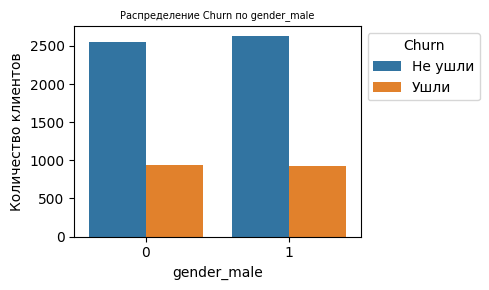

gender_male,0,1
Churn,,
0,0.730791,0.738397
1,0.269209,0.261603


In [20]:
plot_crosstab('gender_male') 
pd.crosstab(source_df['Churn'], source_df['gender_male'], normalize='columns')
# Пол практически не влияет на отток

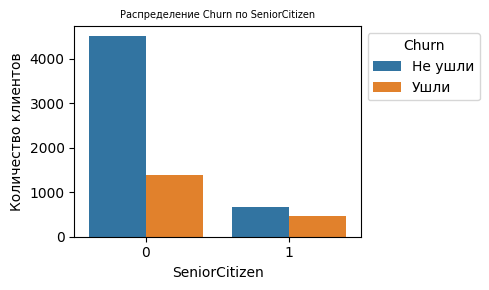

SeniorCitizen,0,1
Churn,,
0,0.763938,0.583187
1,0.236062,0.416813


In [52]:
plot_crosstab('SeniorCitizen')
pd.crosstab(source_df['Churn'], source_df['SeniorCitizen'], normalize='columns')
# Молодых больше в датасете
# Пожилые уходят в ~1.8 раза чаще

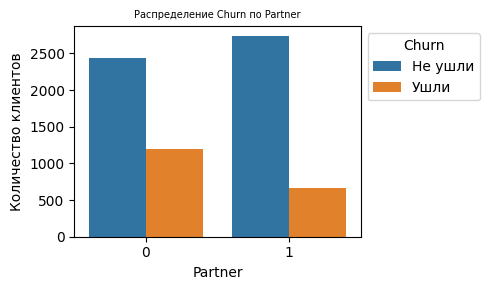

Partner,0,1
Churn,,
0,0.67042,0.803351
1,0.32958,0.196649


In [22]:
plot_crosstab('Partner')
pd.crosstab(source_df['Churn'], source_df['Partner'], normalize='columns')
# Одинокие уходят чаще в ~1.7 раз

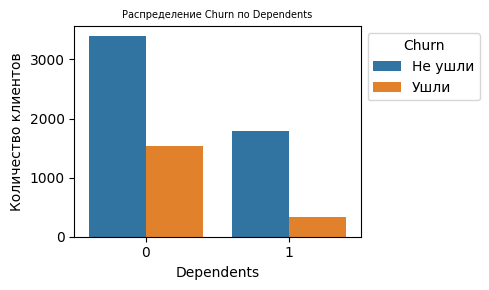

Dependents,0,1
Churn,,
0,0.687209,0.845498
1,0.312791,0.154502


In [23]:
plot_crosstab('Dependents')
pd.crosstab(source_df['Churn'], source_df['Dependents'], normalize='columns')
# Люди без иждевенцев в ~2 раза чаще уходят

**`Онлайн-услуги`**

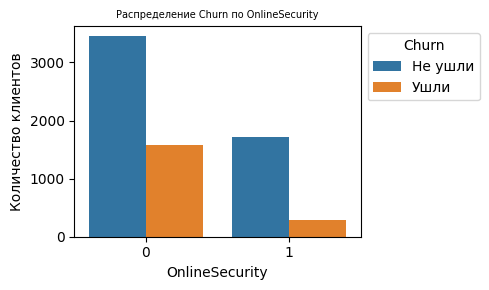

OnlineSecurity,0,1
Churn,,
0,0.686704,0.853888
1,0.313296,0.146112


In [24]:
plot_crosstab('OnlineSecurity')
pd.crosstab(source_df['Churn'], source_df['OnlineSecurity'], normalize='columns')
# Без защиты уходят в ~2.1 раза чаще

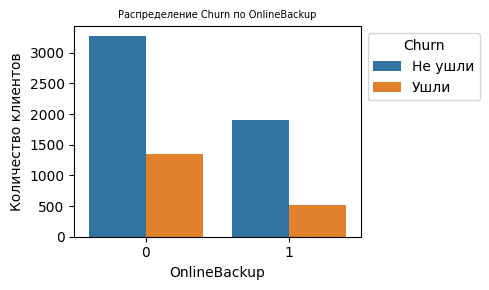

OnlineBackup,0,1
Churn,,
0,0.708279,0.784685
1,0.291721,0.215315


In [25]:
plot_crosstab('OnlineBackup')
pd.crosstab(source_df['Churn'], source_df['OnlineBackup'], normalize='columns')
# Чаще уходят не оформившие OnlineBackup

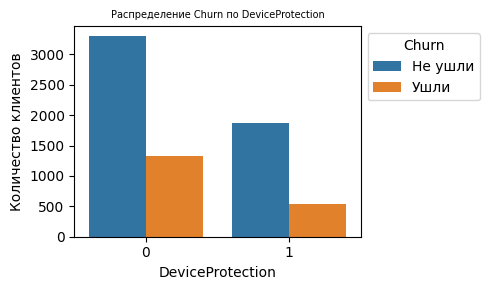

DeviceProtection,0,1
Churn,,
0,0.713482,0.774979
1,0.286518,0.225021


In [26]:
plot_crosstab('DeviceProtection')
pd.crosstab(source_df['Churn'], source_df['DeviceProtection'], normalize='columns')
# Чаще уходят не оформившие DeviceProtection

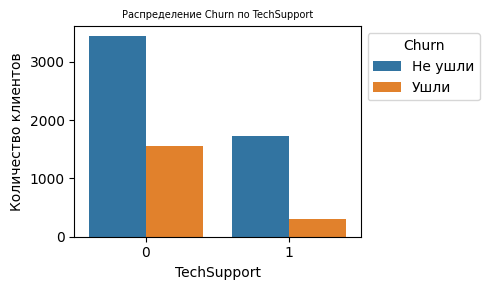

TechSupport,0,1
Churn,,
0,0.688138,0.848337
1,0.311862,0.151663


In [27]:
plot_crosstab('TechSupport')
pd.crosstab(source_df['Churn'], source_df['TechSupport'], normalize='columns')
# Чаще уходят не оформившие TechSupport

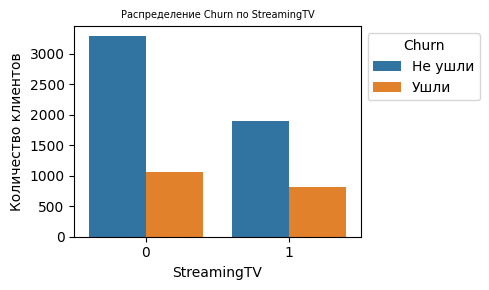

StreamingTV,0,1
Churn,,
0,0.756688,0.699298
1,0.243312,0.300702


In [28]:
plot_crosstab('StreamingTV')
pd.crosstab(source_df['Churn'], source_df['StreamingTV'], normalize='columns')
# Чаще уходят !оформившие! StreamingTV

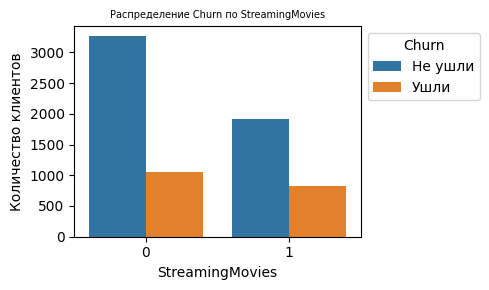

StreamingMovies,0,1
Churn,,
0,0.756205,0.700586
1,0.243795,0.299414


In [29]:
plot_crosstab('StreamingMovies')
pd.crosstab(source_df['Churn'], source_df['StreamingMovies'], normalize='columns')
# Чаще уходят !оформившие! StreamingMovies

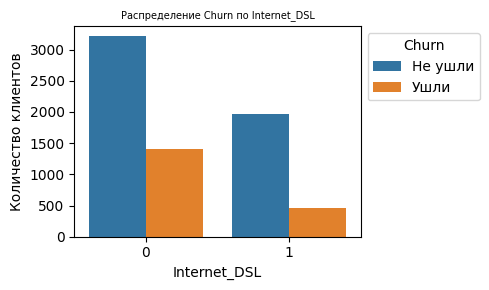

Internet_DSL,0,1
Churn,,
0,0.694937,0.810409
1,0.305063,0.189591


In [30]:
plot_crosstab('Internet_DSL')
pd.crosstab(source_df['Churn'], source_df['Internet_DSL'], normalize='columns')
# Без DSL уходят чаще

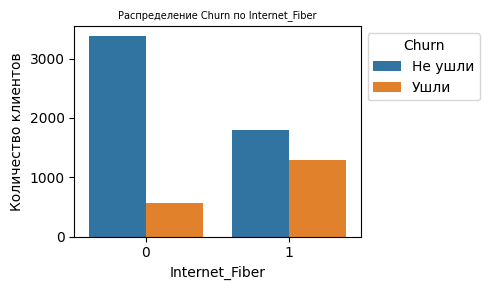

Internet_Fiber,0,1
Churn,,
0,0.85508,0.581072
1,0.14492,0.418928


In [31]:
plot_crosstab('Internet_Fiber')
pd.crosstab(source_df['Churn'], source_df['Internet_Fiber'], normalize='columns')
# С Fiber уходят чаще

In [32]:
pd.crosstab(source_df['Churn'], source_df['Internet_Fiber']+source_df['Internet_DSL'], normalize='columns')
# С Интернетом уходят чаще, но размазываем эффект двух видов

col_0,0,1
Churn,,
0,0.92595,0.681711
1,0.07405,0.318289


**`Телефония`**

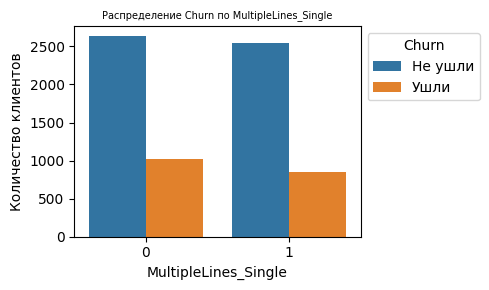

MultipleLines_Single,0,1
Churn,,
0,0.720777,0.749558
1,0.279223,0.250442


In [33]:
plot_crosstab('MultipleLines_Single')
pd.crosstab(source_df['Churn'], source_df['MultipleLines_Single'], normalize='columns')
# Примерно одинаково

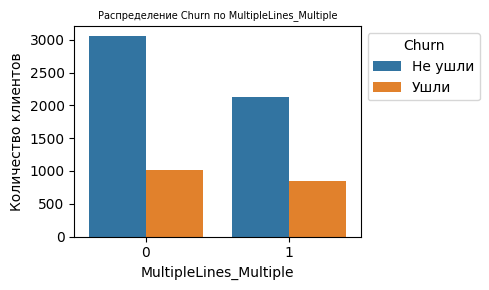

MultipleLines_Multiple,0,1
Churn,,
0,0.749754,0.713901
1,0.250246,0.286099


In [34]:
plot_crosstab('MultipleLines_Multiple')
pd.crosstab(source_df['Churn'], source_df['MultipleLines_Multiple'], normalize='columns')
# Примерно одинаково

In [35]:
pd.crosstab(source_df['Churn'], source_df['MultipleLines_Multiple']+source_df['MultipleLines_Single'], normalize='columns')
# Всё ещё примерно одинаково!

col_0,0,1
Churn,,
0,0.750733,0.732904
1,0.249267,0.267096


**`Фичи взаимодействия с компанией`**: Выставление счёта, Вид оплаты, вид контракта

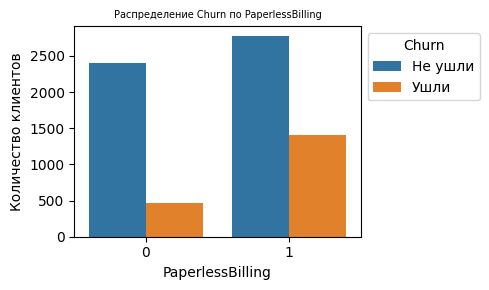

PaperlessBilling,0,1
Churn,,
0,0.836699,0.664349
1,0.163301,0.335651


In [36]:
plot_crosstab('PaperlessBilling')
pd.crosstab(source_df['Churn'], source_df['PaperlessBilling'], normalize='columns')
# Чаще уходят !оформившие! PaperlessBilling

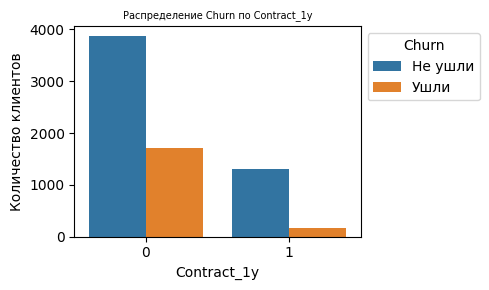

Contract_1y,0,1
Churn,,
0,0.694255,0.887305
1,0.305745,0.112695


In [37]:
plot_crosstab('Contract_1y')
pd.crosstab(source_df['Churn'], source_df['Contract_1y'], normalize='columns')
# Логично, что на долгосрочном контракте уходят меньше

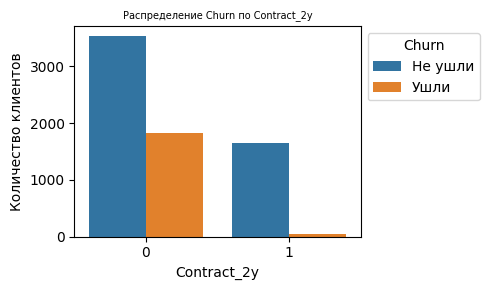

Contract_2y,0,1
Churn,,
0,0.659499,0.971681
1,0.340501,0.028319


In [38]:
plot_crosstab('Contract_2y')
pd.crosstab(source_df['Churn'], source_df['Contract_2y'], normalize='columns')
# Логично, что на ещё болдее долгосрочном контракте уходят ещё меньше

In [39]:
pd.crosstab(source_df['Churn'], source_df['Contract_1y']+source_df['Contract_2y'], normalize='columns')
# col_0=0 Это оалата из месяца в месяц - Такие уходят куда чаще

col_0,0,1
Churn,,
0,0.572903,0.932449
1,0.427097,0.067551


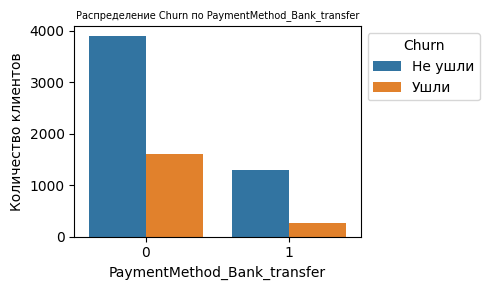

PaymentMethod_Bank_transfer,0,1
Churn,,
0,0.707038,0.832902
1,0.292962,0.167098


In [40]:
plot_crosstab('PaymentMethod_Bank_transfer')
pd.crosstab(source_df['Churn'], source_df['PaymentMethod_Bank_transfer'], normalize='columns')

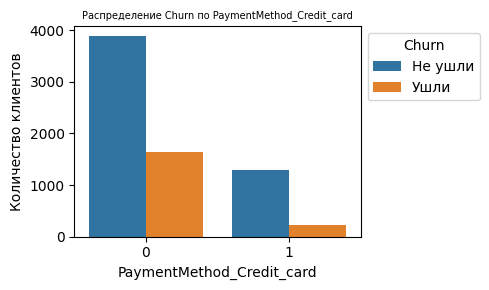

PaymentMethod_Credit_card,0,1
Churn,,
0,0.703496,0.847569
1,0.296504,0.152431


In [41]:
plot_crosstab('PaymentMethod_Credit_card')
pd.crosstab(source_df['Churn'], source_df['PaymentMethod_Credit_card'], normalize='columns')

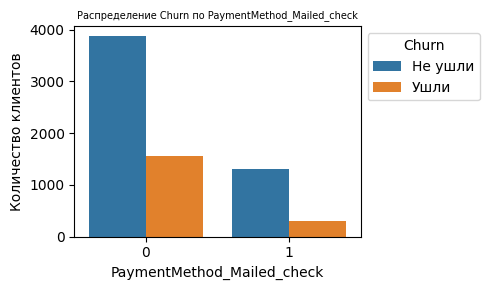

PaymentMethod_Mailed_check,0,1
Churn,,
0,0.712576,0.808933
1,0.287424,0.191067


In [42]:
plot_crosstab('PaymentMethod_Mailed_check')
pd.crosstab(source_df['Churn'], source_df['PaymentMethod_Mailed_check'], normalize='columns')

In [43]:
pd.crosstab(source_df['Churn'], source_df['PaymentMethod_Mailed_check']+source_df['PaymentMethod_Credit_card']+source_df['PaymentMethod_Bank_transfer'], normalize='columns')

col_0,0,1
Churn,,
0,0.547146,0.829414
1,0.452854,0.170586


##### 3.3.2: **Визуальный анализ непрерывных фичей**:

<Axes: xlabel='tenure', ylabel='Count'>

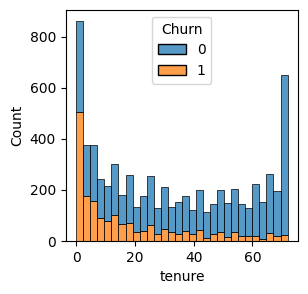

In [130]:
plt.figure(figsize=(3, 3))
sns.histplot(data=source_df, x='tenure', hue='Churn', multiple='stack', bins=30)
# Очевидно, что со временем сохраняются более лояльные клиенты

<Axes: xlabel='TotalCharges', ylabel='Count'>

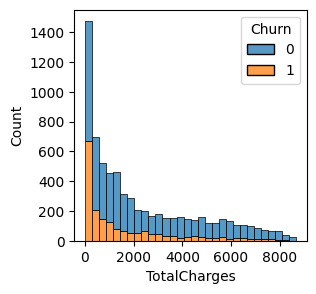

In [134]:
plt.figure(figsize=(3, 3))
sns.histplot(data=source_df, x='TotalCharges', hue='Churn', multiple='stack', bins=30)
# Очевидно, что со временем сохраняются более лояльные клиенты - Здесь сохраняется эта гипотеза

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

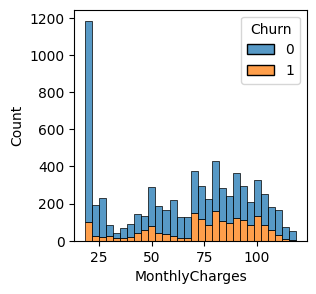

In [135]:
plt.figure(figsize=(3, 3))
sns.histplot(data=source_df, x='MonthlyCharges', hue='Churn', multiple='stack', bins=30)
# Очевидно, что со временем сохраняются более лояльные клиенты

##### 3.3.3: **Mutual Information score**:

Информативность признаков. Будем использовать в качестве референса для выбора наиболее информативных фич.

In [69]:
X = source_df.drop('Churn', axis=1)
y = source_df['Churn']
mi_scores = mutual_info_classif(X, y, random_state=1)
mi_series = pd.DataFrame(zip(X.columns, mi_scores), columns=['feature','mi_score'])
mi_series.sort_values('mi_score',ascending=False).reset_index(drop=True)

,feature,mi_score
0,tenure,0.073348
1,Contract_2y,0.059853
2,Internet_Fiber,0.051916
3,TotalCharges,0.044552
4,MonthlyCharges,0.043761
5,PaperlessBilling,0.021555
6,SeniorCitizen,0.019308
7,OnlineSecurity,0.016390
8,Contract_1y,0.015049
9,Dependents,0.014454


##### 3.3.4: **Матрица корреляций**:

Используем в качестве отбора и отсеивания созависимых признаков

<Axes: >

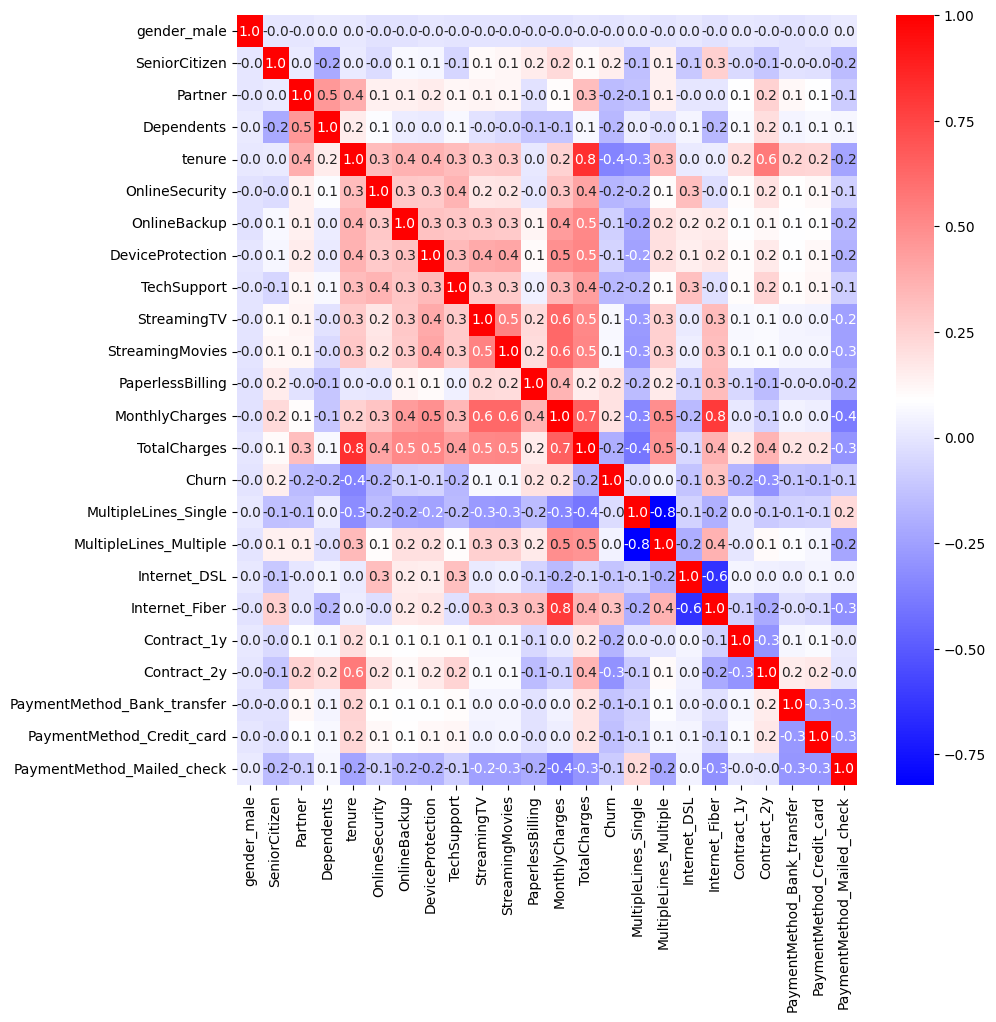

In [95]:
plt.figure(figsize=(10, 10))
sns.heatmap(source_df.corr(), cmap='bwr',annot=True, fmt=".1f")

### **4 Строим модель**: